# This notebook shows how to stack timeseries
## According to different weighting criteria

**Loading necessary packages. Please install packages if not present.**

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy
import array
import random

**Creating array of timeseries populated with Gaussians with randomly varying amplitudes, sigmas, and centres, and random noise**

In [2]:
random.seed()

# Will create 1000 timeseries with 1000 data points each
tms=np.zeros((1000,1000))

# Adding the Gaussians first
for i in range(1000):
    cno=random.randrange(0,50)
    nno=0-(50-cno)
    tms[i,cno:nno]=0.1*random.randrange(0,50)*scipy.signal.windows.gaussian(950,random.randrange(100))
    tms[i,:]+=0.05*random.randrange(0,100)*np.random.rand(1000)

/Users/sambit/my-notebook-project/project-venv/lib/python3.13/site-packages/scipy/signal/windows/_windows.py:1379: RuntimeWarning: divide by zero encountered in divide
  w = np.exp(-n ** 2 / sig2)


**Checking 10 random timeseries**

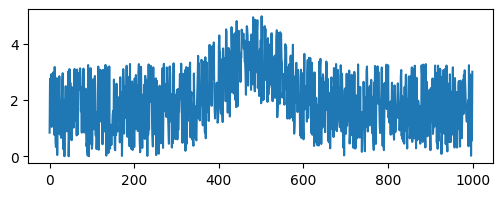

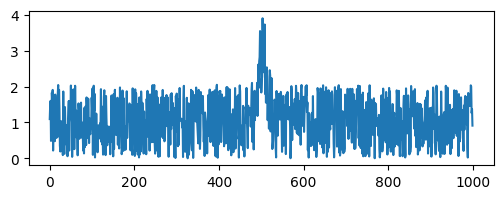

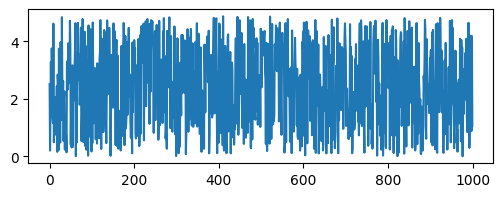

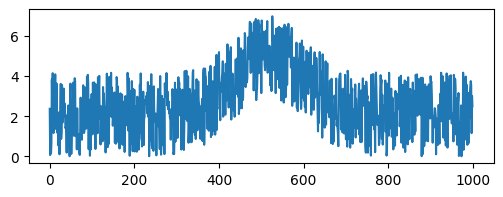

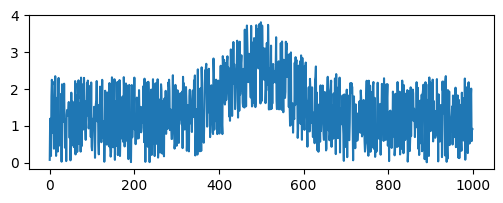

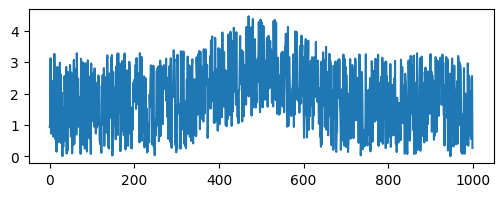

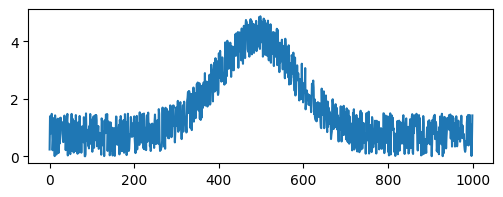

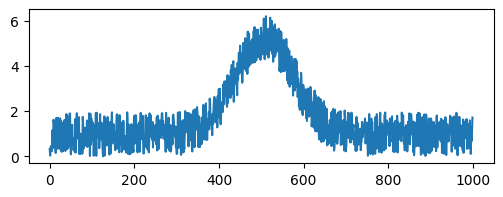

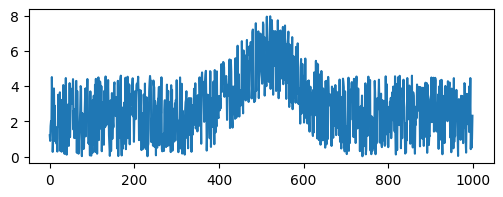

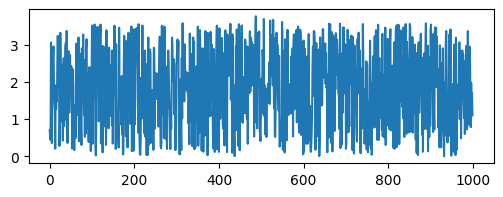

In [3]:
for i in range(10):
    plt.figure(figsize=(6,2))
    plt.plot(tms[random.randrange(0,999),:])

**Unweighted stacks**

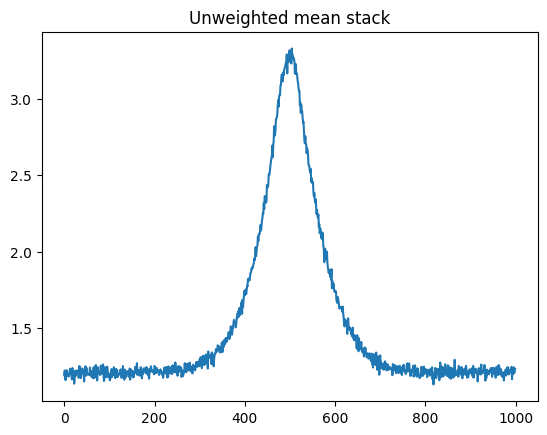

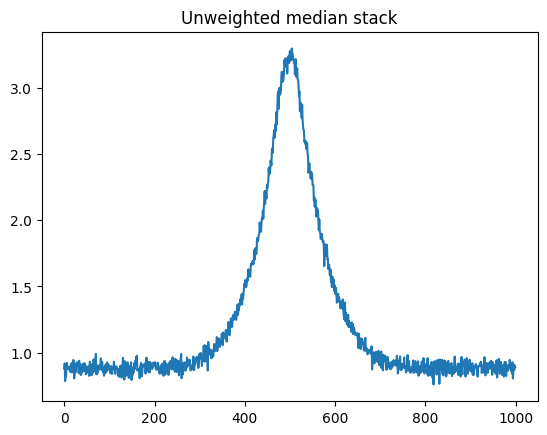

In [4]:
# Mean stack
meanst=np.zeros((1,1000))

for i in range(1000):
    meanst[0,i]=np.nanmean(tms[:,i])

plt.figure()
plt.title('Unweighted mean stack')
plt.plot(meanst[0,:])
plt.show()

# Median stack
medianst=np.zeros((1,1000))

for i in range(1000):
    medianst[0,i]=np.nanmedian(tms[:,i])

plt.figure()
plt.title('Unweighted median stack')
plt.plot(medianst[0,:])
plt.show()

**Defining noise based normalized weights**

In [5]:
wts=np.zeros(1000)
rmss=np.zeros(1000)

for i in range(1000):
    rmsspec=np.concatenate((tms[i,:100],tms[i,-101:-1]))
    rmss[i]=np.nanstd(rmsspec)

# Will ignore outlier spectra assigned very low noise values
mad=scipy.stats.median_abs_deviation(np.log10(rmss))
rmss[(mad-np.log10(rmss[:]))>3]=0

for i in range(1000):
    if rmss[i]==0:
        wts[i]=np.nan
        tms[i,:]=np.nan
    else:
        wts[i]=1./rmss[i]

wtsum=np.nansum(wts[:])
wts/=wtsum

/var/folders/_8/scf0b0g13g9f9vr2vtljc8480000gn/T/ipykernel_49057/3588755747.py:9: RuntimeWarning: divide by zero encountered in log10
  mad=scipy.stats.median_abs_deviation(np.log10(rmss))
/var/folders/_8/scf0b0g13g9f9vr2vtljc8480000gn/T/ipykernel_49057/3588755747.py:10: RuntimeWarning: divide by zero encountered in log10
  rmss[(mad-np.log10(rmss[:]))>3]=0


**Noise weighted mean stack**

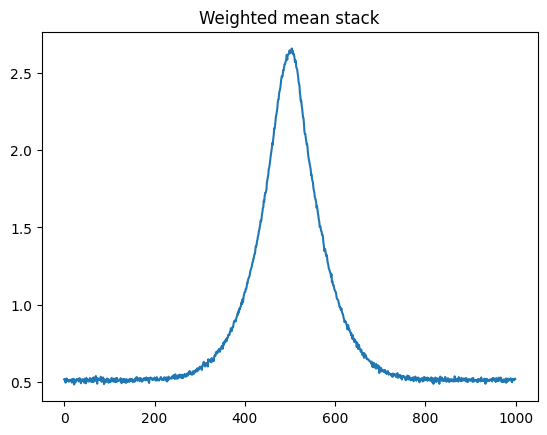

In [6]:
# Mean stack
nmeanst=np.zeros((1,1000))

nmska=np.zeros(1000)
mska=nmska.astype(bool)

for i in range(1000):
    if math.isnan(wts[i])==True:
        mska[i]=True

for i in range(1000):
    tmsm=np.ma.array(tms[:,i],mask=mska)
    nmeanst[0,i]=np.ma.average(tmsm, weights=wts)

plt.figure()
plt.title('Weighted mean stack')
plt.plot(nmeanst[0,:])
plt.show()